## 주택 가격

#### - 컬럼 설명 : HousePrice_description.txt 참고

In [1]:
import pandas as pd

house = pd.read_csv('HousePrice.csv')
house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
house.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

### 주어진 데이터를 이용하여 'SalePrice' 를 예측하는 모델을 만든다고 가정하고 다음 EDA를 진행하시오.

#### 1. 각 변수의 기술통계량을 알아보시오.
#### 2. Target 변수의 분포를 파악하시오.
#### 3. 각 변수들의 상관관계를 파악하시오.
#### 4. 각 변수들의 이상치를 검출하시오.
#### 5. 모델 생성을 위한 중요변수를 도출하시오.

In [3]:
# 기술 통계량
house.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
# missing value
missing = house.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()

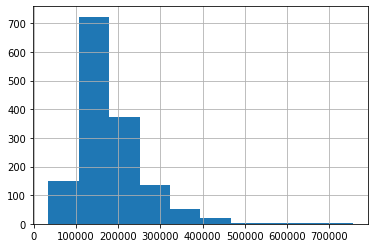

In [6]:
# target value 분포
import matplotlib.pyplot as plt
%matplotlib inline

house['SalePrice'].hist()

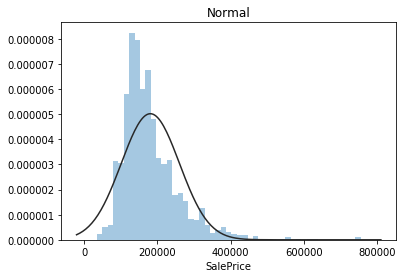

In [7]:
# target value 분포, KDE 추가
import scipy.stats as st
import seaborn as sns

plt.figure()
plt.title('Normal')
sns.distplot(house['SalePrice'], kde=False, fit=st.norm)


In [8]:
# 정규성 확인
quantitative = [f for f in house.columns if house.dtypes[f] != 'object']
quantitative.remove('Id')

test_normality = lambda x: st.shapiro(x.fillna(0))[1] > 0.05
normal = house[quantitative].apply(test_normality)
normal

MSSubClass       False
LotFrontage      False
LotArea          False
OverallQual      False
OverallCond      False
YearBuilt        False
YearRemodAdd     False
MasVnrArea       False
BsmtFinSF1       False
BsmtFinSF2       False
BsmtUnfSF        False
TotalBsmtSF      False
1stFlrSF         False
2ndFlrSF         False
LowQualFinSF     False
GrLivArea        False
BsmtFullBath     False
BsmtHalfBath     False
FullBath         False
HalfBath         False
BedroomAbvGr     False
KitchenAbvGr     False
TotRmsAbvGrd     False
Fireplaces       False
GarageYrBlt      False
GarageCars       False
GarageArea       False
WoodDeckSF       False
OpenPorchSF      False
EnclosedPorch    False
3SsnPorch        False
ScreenPorch      False
PoolArea         False
MiscVal          False
MoSold           False
YrSold           False
SalePrice        False
dtype: bool

In [9]:
# category 변수 별 Target 값의 분포 확인

categorical = [f for f in house.columns if house.dtypes[f] == 'object']

def boxplot(x, y, **kwargs):
    sns.boxplot(x=x, y=y)
    x=plt.xticks(rotation=90)
    
f = pd.melt(house, id_vars=['SalePrice'], value_vars=categorical)
f

,SalePrice,variable,value
0,208500,MSZoning,RL
1,181500,MSZoning,RL
2,223500,MSZoning,RL
3,140000,MSZoning,RL
4,250000,MSZoning,RL
...,...,...,...
62775,175000,SaleCondition,Normal
62776,210000,SaleCondition,Normal
62777,266500,SaleCondition,Normal
62778,142125,SaleCondition,Normal


/Users/iwannab1/miniconda3/envs/edu/lib/python3.7/site-packages/seaborn/axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


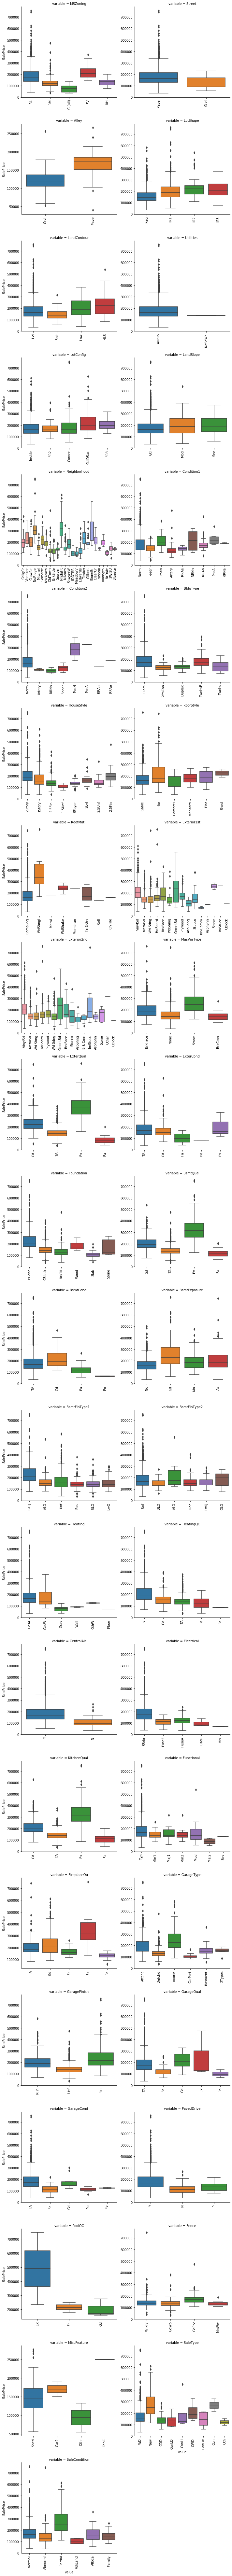

In [10]:
g = sns.FacetGrid(f, col="variable",  col_wrap=2, sharex=False, sharey=False, size=5)
g = g.map(boxplot, "value", "SalePrice")

In [16]:
# category별 anova 분석
from statsmodels.formula.api import ols
import statsmodels.api as sm

results = ols('SalePrice ~ C(PoolQC)', house).fit()
anova = sm.stats.anova_lm(results)

In [17]:
anova  # p-value > 0.05 이므로 그룹의 평균값이 통계적으로 유의미한 차이가 없다.

,df,sum_sq,mean_sq,F,PR(>F)
C(PoolQC),2.0,1.143135e+11,5.715676e+10,1.627469,0.303985
Residual,4.0,1.404801e+11,3.512003e+10,NaN,NaN


In [20]:
def anova(column):
    model = ols('SalePrice ~ C(%s)' % column, house).fit()
    result = sm.stats.anova_lm(model)
    if result['PR(>F)'][0] < 0.05:
        return ' 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.'
    return ' 그룹간의 평균값이 통계적으로 유의미한 차이가 없다.'
    
for c in categorical:
    print(c + anova(c))

MSZoning 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
Street 그룹간의 평균값이 통계적으로 유의미한 차이가 없다.
Alley 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
LotShape 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
LandContour 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
Utilities 그룹간의 평균값이 통계적으로 유의미한 차이가 없다.
LotConfig 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
LandSlope 그룹간의 평균값이 통계적으로 유의미한 차이가 없다.
Neighborhood 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
Condition1 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
Condition2 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
BldgType 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
HouseStyle 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
RoofStyle 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
RoofMatl 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
Exterior1st 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
Exterior2nd 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
MasVnrType 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
ExterQual 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
ExterCond 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
Foundation 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
BsmtQual 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
BsmtCond 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
BsmtExposure 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
BsmtFinType1 그룹간의 평균값이 통계적으로 유의미한 차이가 있다.
BsmtFinType2 그룹간의 

In [26]:
# 데이터를 가장 잘 분류하는 category 변수 찾기

diversity = {}
def anova(column):
    
    model = ols('SalePrice ~ C(%s)' % column, house).fit()
    result = sm.stats.anova_lm(model)
    diversity[column] = result['PR(>F)'][0]
    
for c in categorical:
    anova(c)
    
    
diversity = sorted(diversity.items(), key=(lambda x : x[1]))
diverDF = pd.DataFrame(diversity)
diverDF

,0,1
0,Neighborhood,1.558600e-225
1,ExterQual,1.439551e-204
2,KitchenQual,3.032213e-192
3,BsmtQual,9.610615e-186
4,GarageFinish,1.199117e-93
5,Foundation,5.791895e-91
6,HeatingQC,2.667062e-67
7,GarageType,1.247154e-66
8,MasVnrType,4.793331e-65
9,BsmtFinType1,1.807731e-63


In [28]:
import numpy as np

diverDF.columns = ['category', 'diversity']
diverDF['diversity'] = diverDF['diversity'].apply(lambda x : np.log(1/x))
diverDF

,category,diversity
0,Neighborhood,517.637858
1,ExterQual,469.363028
2,KitchenQual,440.987045
3,BsmtQual,426.017959
4,GarageFinish,213.958829
5,Foundation,207.778784
6,HeatingQC,153.292224
7,GarageType,151.749752
8,MasVnrType,148.100805
9,BsmtFinType1,144.470788


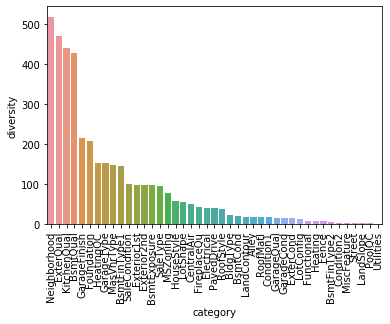

In [31]:
sns.barplot(data=diverDF, x='category', y='diversity');
x=plt.xticks(rotation=90)

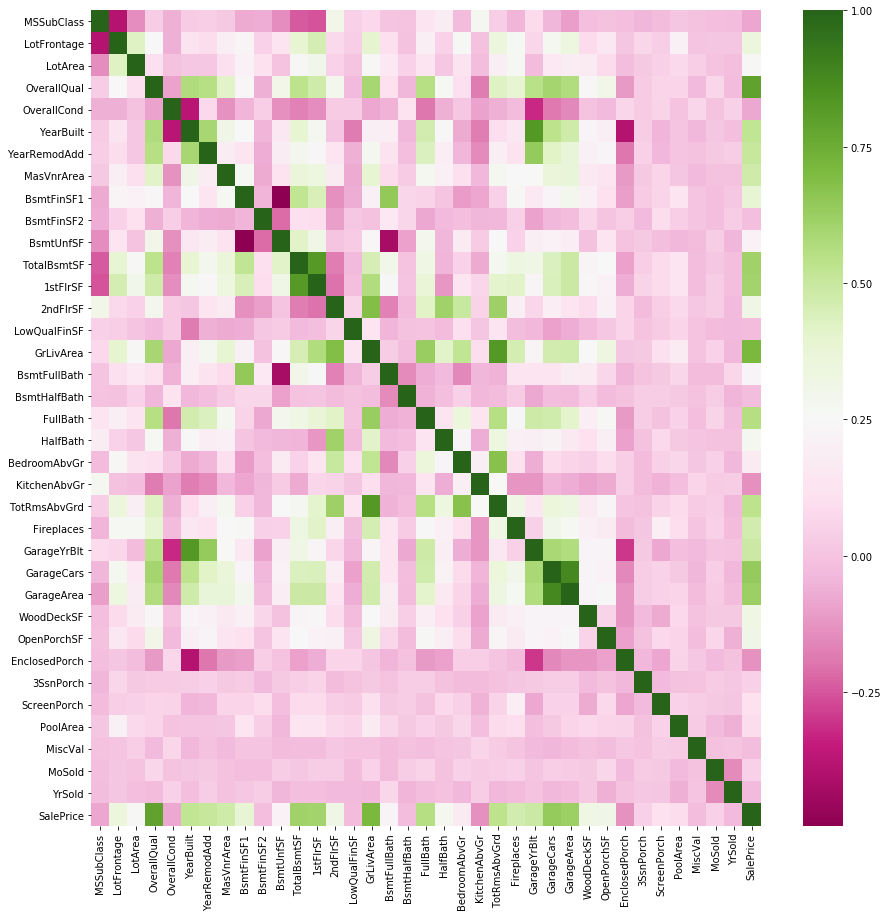

In [39]:
# 상관관계 분석

corr = house[quantitative].corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr, cmap='PiYG')

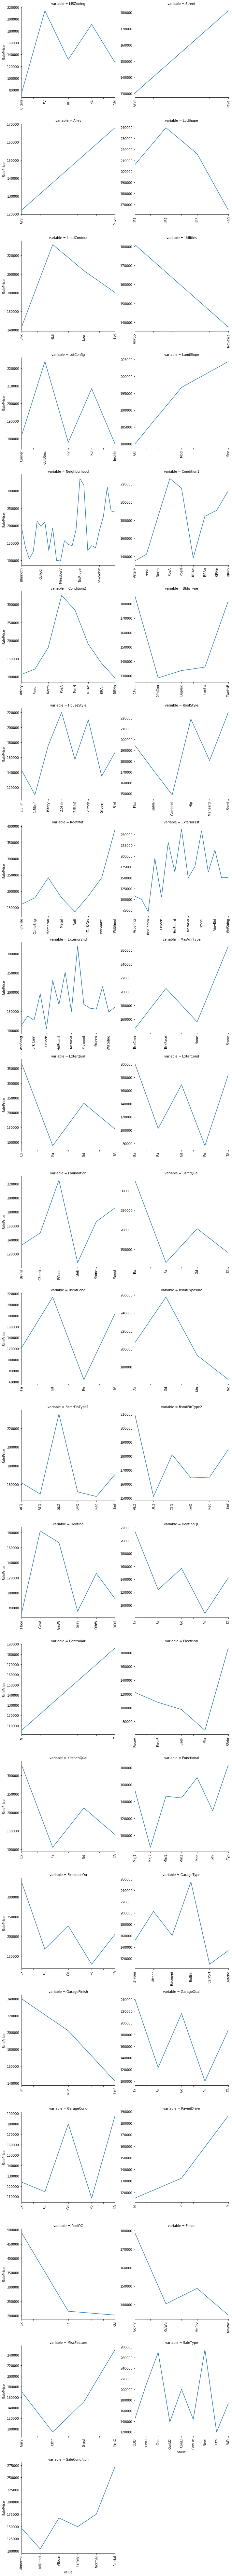

In [44]:
# 각 그룹별 SalePrice 평균

def pairplot(x, y, **kwargs):
    ax = plt.gca()
    ts = pd.DataFrame({'time': x, 'val': y})
    ts = ts.groupby('time').mean()
    ts.plot(ax=ax)
    plt.xticks(rotation=90)

g = sns.FacetGrid(f, col="variable",  col_wrap=2, sharex=False, sharey=False, size=5)
g = g.map(pairplot, "value", "SalePrice")

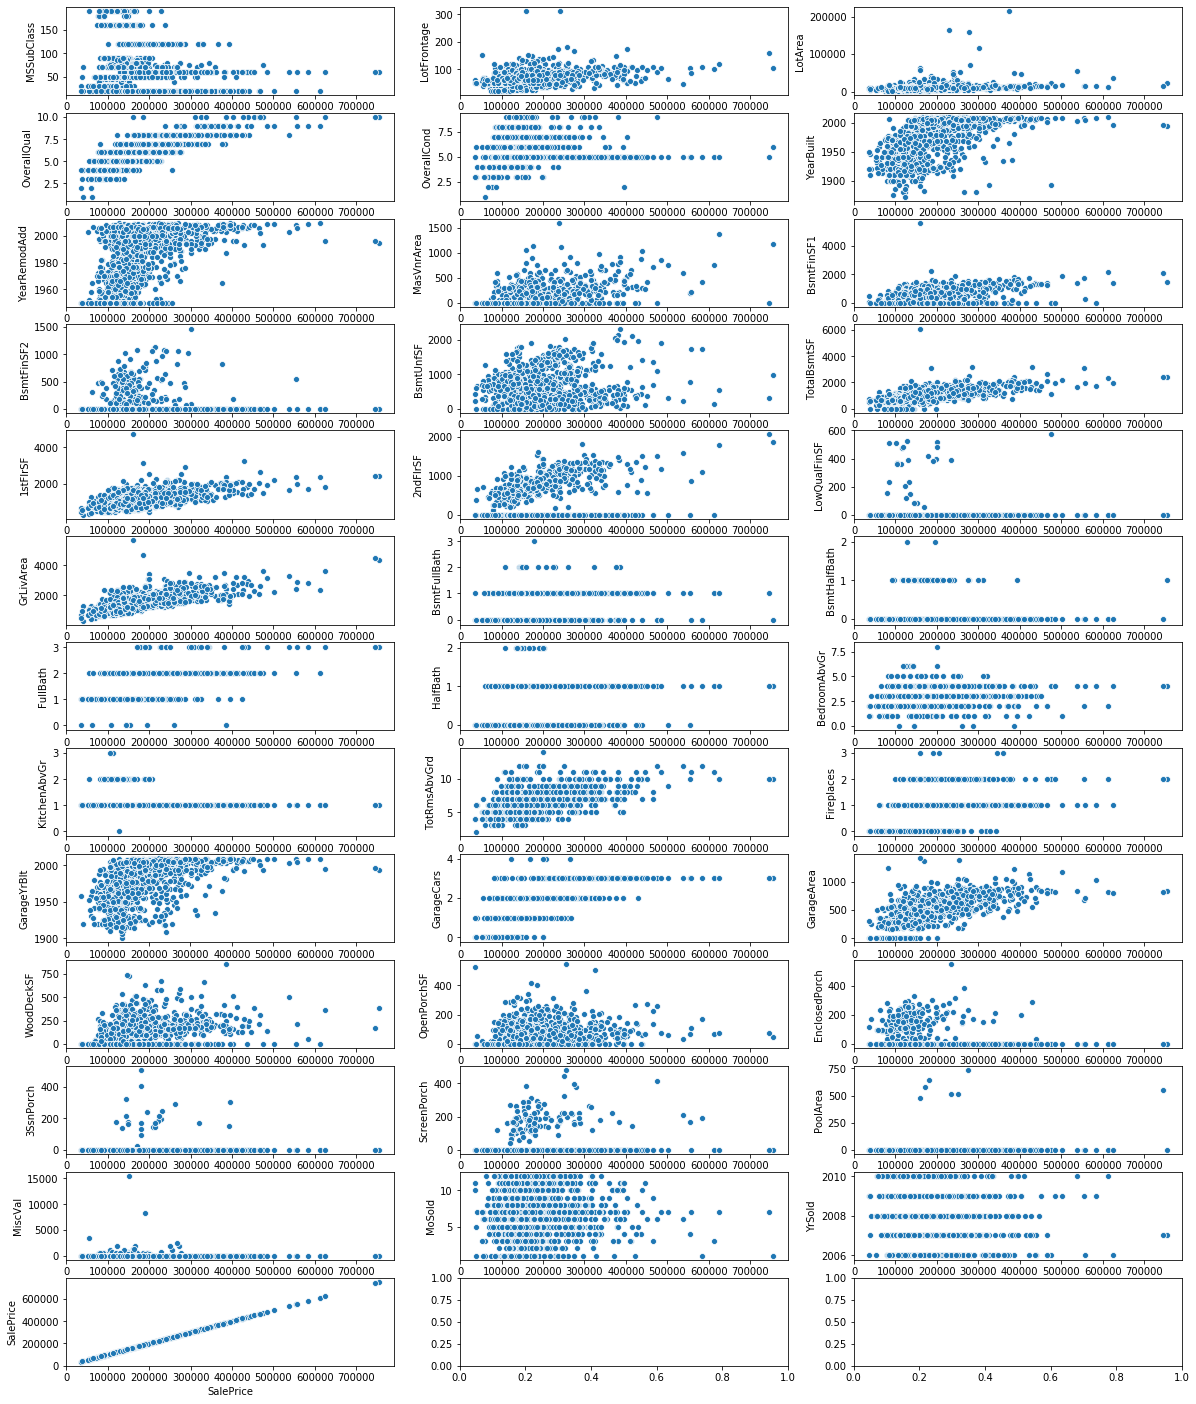

In [86]:
# 변수간 상관관계 (Scatter)

rowcnt = len(quantitative) // 3 if len(quantitative) % 3 == 0 else len(quantitative) // 3 + 1

fig, ax = plt.subplots(rowcnt, 3, figsize=(20, 25))

for i in range(rowcnt):
    for j in range(3):
        colidx = i*3 + j 
        if colidx == len(quantitative):
            break
        sns.scatterplot(house['SalePrice'], house[quantitative[i*3 + j]], ax=ax[i, j])
